In [2]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive")

# Load market data for each symbol (example with 7 symbols)
symbols = ['2yr', '3yr', '5yr', '7yr', '10yr', '20yr', '30yr']
market_data = {}
for symbol in symbols:
    market_data[symbol] = pd.read_csv(f'/content/drive/MyDrive/r8fin/{symbol}_combined_result.csv')

# Load trading data (with mixed symbols)
trading_data = pd.read_parquet('/content/drive/MyDrive/r8fin/merged_r8fin_trades.parquet')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
trading_data

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,order_text,quote_or_hedge,hedge_target_price,cash_exchange_trade_id,timestamp,build_id,build_name,hide_duration,pop_ticks,label
0,2024-09-16,2024-09-13 07:15:38.351,NaT,2024-09-13 03:15:38.351,574483.0,550692610,7024116908,696111430.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
1,2024-09-16,2024-09-13 07:15:38.360,NaT,2024-09-13 03:15:38.360,574483.0,550692610,7024116908,696111431.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
2,2024-09-16,2024-09-13 07:15:39.964,NaT,2024-09-13 03:15:39.964,574483.0,550692629,7024116908,696111455.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
3,2024-09-16,2024-09-13 07:15:40.128,NaT,2024-09-13 03:15:40.128,574483.0,550692629,7024116908,696111456.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
4,2024-09-16,2024-09-13 07:15:39.963,NaT,2024-09-13 03:15:39.963,574483.0,550692627,7024116908,696111462.0,ZUMLOTRS,MVXHXVKU,...,None,Other,NaN,None,1.726212e+18,110806.0,New Build,0.0,"comp_0: 6.0, comp_1: 0.0",r8fin_trades
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5923554,2024-10-04,2024-10-04 20:59:06.135,2024-10-04 20:59:06.128,2024-10-04 16:59:06.128,590551.0,7029292600,7029291632,699617037.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 29@112.921875), -0.737...",Hedge,98.630859,5629609485429684499,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades
5923555,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.130,2024-10-04 16:59:06.130,590551.0,7029292601,7029291632,699617036.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 57@112.921875), -0.737...",Hedge,98.630859,5629609485429684503,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades
5923556,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.131,2024-10-04 16:59:06.131,590551.0,7029292601,7029291632,699617034.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 57@112.921875), -0.737...",Hedge,98.630859,5629609485429684505,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades
5923557,2024-10-04,2024-10-04 20:59:06.138,2024-10-04 20:59:06.132,2024-10-04 16:59:06.132,590551.0,7029292602,7029291632,699617033.0,CNKMYOTP,NKHTRYPK,...,"Hedge (of CBOT TYZ4 BOT 43@112.921875), -0.737...",Hedge,98.630859,5629609485429684507,1.728076e+18,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades


In [4]:
trading_data.columns

Index(['trade_date', 'executiontime', 'brokerexecutiontime', 'exec_time_et',
       'recapid', 'orderid', 'parentcorrelationorderid', 'executionid', 'firm',
       'client', 'syntheticcontractidentifier', 'instrument',
       'syntheticpricemode', 'syntheticticksize',
       'syntheticcontractdefinition', 'security_type', 'symbol', 'cusip',
       'side', 'quantity', 'price', 'order_source', 'broker_id', 'exchange',
       'exchange_route', 'exchange_endoint', 'exchange_lp', 'is_aggressive',
       'destination', 'order_text', 'quote_or_hedge', 'hedge_target_price',
       'cash_exchange_trade_id', 'timestamp', 'build_id', 'build_name',
       'hide_duration', 'pop_ticks', 'label'],
      dtype='object')

In [5]:
trading_data['instrument']

,instrument
0,Z XM ROLL 1.8% FRONTS
1,Z XM ROLL 1.8% FRONTS
2,Z XM ROLL 1.8% FRONTS
3,Z XM ROLL 1.8% FRONTS
4,Z XM ROLL 1.8% FRONTS
...,...
5923554,CT5-TYZ4-CT10 (TYFLY) (Y)
5923555,CT5-TYZ4-CT10 (TYFLY) (Y)
5923556,CT5-TYZ4-CT10 (TYFLY) (Y)
5923557,CT5-TYZ4-CT10 (TYFLY) (Y)


In [6]:
trading_data['is_aggressive'].unique()

array([nan,  0.,  1.])

In [7]:
trading_data['side'].unique()

array(['B', 'S'], dtype=object)

In [8]:
trading_data['symbol'].unique()

array(['SFE XMU4-XMZ4', 'SFE XMZ4', 'SFE YMZ4', 'SFE YMU4-YMZ4',
       'CBOT TYZ4', 'CBOT WNZ4', 'CBOT TUZ4', 'CME SFRZ5', 'CBOT FFV4',
       'EUREX UBZ4', 'EUREX OEZ4', 'CBOT FFN5-FFQ5', 'EUREX DUZ4',
       'IFLL ERZ4', 'ME CVZ4', 'ME CNZ4', 'ME CORH5', 'ME CORZ4',
       'ME CORZ5', 'ME CORU5', 'ME CORH6', 'ME CORM5', 'ME XQZ4',
       'CME SFRH5', 'CME SERV4-FFV4', 'CBOT FFX4', 'CBOT FFU4',
       'CBOT USZ4', 'CBOT UXYZ4', 'CBOT FVZ4', 'ME CORM6',
       'CME SFR:AB 02Y Z4', 'CME SFRZ4', 'CME SERU4', 'EUREX IKZ4',
       'EUREX RXZ4', 'CME SERV4', 'CME SERX4', 'IFLL ERU5', 'EUREX OATZ4',
       'EUREX BTSZ4', 'CME SFR:BF M6-U6-Z6', 'CME SERF5-FFF5',
       'CME SFRZ4-SFRZ5', 'CME SFR:AB 01Y Z4', 'CME SFR:AB 01Y Z7',
       'CME SFR:AB 01Y Z6', 'CME SFR:AB 01Y Z5', 'CME SFRU4', 'CME SFRZ8',
       'CME SFRH9', 'CME SFRM9', 'CME SFR:AB 05Y Z4', 'CME SFR:AB 03Y Z4',
       'CME SFRM5', 'CME SFRU5', 'CME SFRU6', 'CME SFRM6', 'IFLL G Z4',
       'CME SFRH8', 'CME SFRZ6', 'CME SFRH6',

# how many trades for each symbol

In [9]:
# Count the number of trades for each symbol
symbol_trade_counts = trading_data['symbol'].value_counts()
print(symbol_trade_counts.head(40))

symbol
5 Year                 535599
10 Year                387564
CME SFR:AB 03Y Z4      292452
CME SFR:AB 03Y U4      270612
2 Year                 252525
3 Year                 215598
CME SFR:AB 02Y U4      208608
CME SFR:AB 02Y Z4      201048
30 Year                177066
7 Year                 173103
CBOT TUZ4              162625
CBOT FVZ4              157161
CME SFR:AB 05Y Z4      154860
CBOT TYZ4              125117
CME SFR:AB 05Y U4      118780
CBOT UXYZ4              92436
EUREX RXZ4              83367
20 Year                 76921
CBOT WNZ4               75073
CBOT FVU4               70188
CBOT TUU4               70158
CME SFR:AB 01Y Z4       68044
CBOT USZ4               58088
CME SFR:AB 01Y U4       57790
CME SFR:AB 01Y U5       53626
CBOT TYU4               53218
CME SFR:AB 01Y Z5       48488
EUREX DUZ4              47386
IFLL SFI: BNDLY2 U4     44904
EUREX OEZ4              36107
CBOT UXYU4              33791
CBOT WNU4               31958
CME SFRZ5               31284
CME

In [10]:
specific_symbols = ['20 Year O1', '10 Year O1', '30 Year O1', '7 Year O1', '5 Year O1', '3 Year O1', '7 Year O2']

# Get the trade counts for the specific symbols
specific_symbol_counts = symbol_trade_counts[symbol_trade_counts.index.isin(specific_symbols)]
print(specific_symbol_counts)

symbol
10 Year O1    1209
5 Year O1      340
7 Year O1      238
20 Year O1     112
3 Year O1       34
30 Year O1      16
7 Year O2        2
Name: count, dtype: int64


# look the difference between '10 Year'and '10 Year O1'

In [11]:
trading_data['quote_or_hedge'].unique()

array(['Other', 'Hedge', 'Quote'], dtype=object)

In [12]:
trading_data['quantity']

,quantity
0,171.0
1,171.0
2,65.0
3,65.0
4,4.0
...,...
5923554,1.0
5923555,1.0
5923556,3.0
5923557,1.0


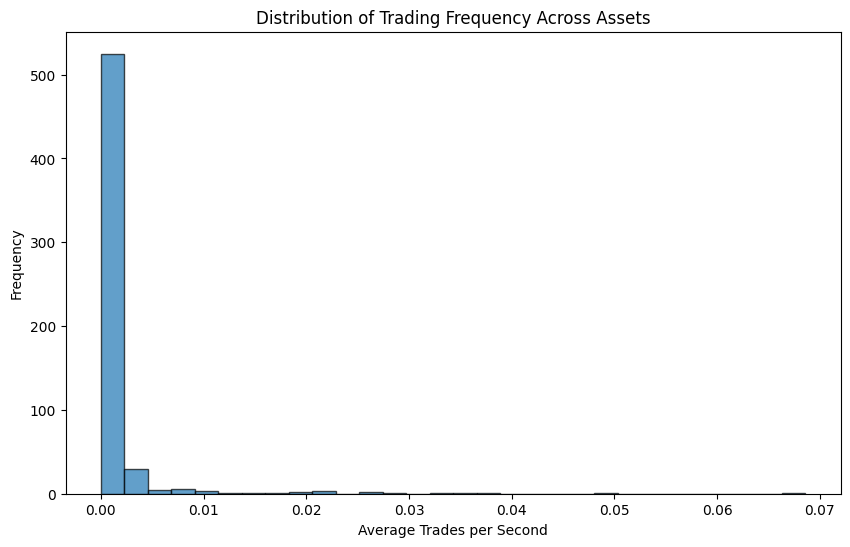

count    5.850000e+02
mean     1.296745e-03
std      5.254958e-03
min      1.280642e-07
25%      6.915468e-06
50%      3.739475e-05
75%      3.310460e-04
max      6.859107e-02
dtype: float64


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

trading_data['timestamp'] = pd.to_datetime(trading_data['timestamp'])


trading_data['time_diff'] = trading_data['timestamp'].diff().dt.total_seconds()

# Calculate the number of trades per second

# The frequency of trades per second for each asset can be calculated by dividing the number of trades by the total duration in seconds
frequency = trading_data.groupby('symbol').size() / (trading_data['timestamp'].max() - trading_data['timestamp'].min()).total_seconds()


plt.figure(figsize=(10, 6))
plt.hist(frequency, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Average Trades per Second')
plt.ylabel('Frequency')
plt.title('Distribution of Trading Frequency Across Assets')
plt.show()

print(frequency.describe())

In [14]:
# Calculate the total number of trades per symbol
total_trades = trading_data.groupby('symbol').size()

# Calculate the total market hours (assuming the market opens at 9:30 AM and closes at 4:00 PM)
market_start_time = pd.to_datetime('09:30:00')
market_end_time = pd.to_datetime('16:00:00')
market_duration_seconds = (market_end_time - market_start_time).seconds

min_bin_size_seconds = market_duration_seconds / (total_trades / 20)  # Bin size ensuring at least 10 trades

# Check for the minimum bin size that ensures 10-20 trades
min_bin_size_seconds

,0
symbol,
10 Year,1.207542
10 Year O1,387.096774
2 Year,1.853282
20 Year,6.084164
20 Year O1,4178.571429
...,...
SFE YMU4-YMZ4,1368.421053
SFE YMU4XMU4,1779.467681
SFE YMZ4,3162.162162


In [15]:
min_bin_size_seconds.head(20)

,0
symbol,
10 Year,1.207542
10 Year O1,387.096774
2 Year,1.853282
20 Year,6.084164
20 Year O1,4178.571429
3 Year,2.170707
3 Year O1,13764.705882
30 Year,2.643082
30 Year O1,29250.000000


In [16]:
import pandas as pd

trading_data['timestamp'] = pd.to_datetime(trading_data['timestamp'])

# 'B' for Buy, 'S' for Sell
trading_data['order_flow'] = trading_data['side'].map({'B': 1, 'S': -1}) * trading_data['quantity']

# Round the timestamp to the nearest 10 seconds for grouping
trading_data['time_rounded'] = trading_data['timestamp'].dt.floor('10S')

# Group by the rounded timestamp and sum the order flows for each 10-second interval
order_flow_aggregated = trading_data.groupby('time_rounded')['order_flow'].sum().reset_index()

<ipython-input-16-4ee5daf0781f>:9: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  trading_data['time_rounded'] = trading_data['timestamp'].dt.floor('10S')


In [17]:
order_flow_aggregated

,time_rounded,order_flow
0,2024-08-02 11:56:30,-17.0
1,2024-08-02 12:03:00,-51.0
2,2024-08-02 12:03:30,-81.0
3,2024-08-02 12:03:40,-23.0
4,2024-08-02 12:33:40,15.0
...,...,...
229171,2024-10-31 20:59:00,-11.0
229172,2024-10-31 20:59:10,-140.0
229173,2024-10-31 20:59:20,4.0
229174,2024-10-31 20:59:30,-20.0


# Mapping Trade and Market Data

The market data is recorded at 10-second intervals, meaning that within each 10-second window, the bid and ask prices are assumed to remain constant. To align the trading data with the corresponding market conditions, we round the executiontime in the trading data to the 10 seconds. This ensures that each trade is matched with the correct bid and ask price available at that time interval.

In [18]:
# Convert execution time to datetime format
trading_data['executiontime'] = pd.to_datetime(trading_data['executiontime'])

# Round execution time down to the nearest 10 seconds
trading_data['executiontime_10s'] = trading_data['executiontime'].dt.floor('10S')

<ipython-input-18-8dce5fdf3f77>:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  trading_data['executiontime_10s'] = trading_data['executiontime'].dt.floor('10S')


In [19]:
trading_data[['executiontime', 'symbol', 'executiontime_10s']]

,executiontime,symbol,executiontime_10s
0,2024-09-13 07:15:38.351,SFE XMU4-XMZ4,2024-09-13 07:15:30
1,2024-09-13 07:15:38.360,SFE XMU4-XMZ4,2024-09-13 07:15:30
2,2024-09-13 07:15:39.964,SFE XMU4-XMZ4,2024-09-13 07:15:30
3,2024-09-13 07:15:40.128,SFE XMU4-XMZ4,2024-09-13 07:15:40
4,2024-09-13 07:15:39.963,SFE XMZ4,2024-09-13 07:15:30
...,...,...,...
5923554,2024-10-04 20:59:06.135,5 Year,2024-10-04 20:59:00
5923555,2024-10-04 20:59:06.136,5 Year,2024-10-04 20:59:00
5923556,2024-10-04 20:59:06.136,5 Year,2024-10-04 20:59:00
5923557,2024-10-04 20:59:06.138,5 Year,2024-10-04 20:59:00


Filter a subdataframe with only symbols in ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']

In [20]:
# Define the list of symbols that are standard maturities and can be mapped to market data
maturity_symbols = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']

# Filter the trading data to include only rows with the selected maturity symbols
filtered_trading_data = trading_data[trading_data['symbol'].isin(maturity_symbols)]

In [21]:
filtered_trading_data

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,timestamp,build_id,build_name,hide_duration,pop_ticks,label,time_diff,order_flow,time_rounded,executiontime_10s
79861,2024-09-16,2024-09-16 06:32:33.514,2024-09-16 06:32:33.512,2024-09-16 02:32:33.512,575316.0,7024412350,7024412350,696312820.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:32:33.513999872,NaN,None,NaN,None,r8fin_trades,-52006.454,-1.0,2024-09-16 06:32:30,2024-09-16 06:32:30
79862,2024-09-16,2024-09-16 06:32:57.002,2024-09-16 06:32:57.002,2024-09-16 02:32:57.002,575316.0,7024412350,7024412350,696312821.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:32:57.002000128,NaN,None,NaN,None,r8fin_trades,23.488,-1.0,2024-09-16 06:32:50,2024-09-16 06:32:50
79863,2024-09-16,2024-09-16 06:33:01.095,2024-09-16 06:33:01.093,2024-09-16 02:33:01.093,575316.0,7024412350,7024412350,696312822.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:33:01.095000064,NaN,None,NaN,None,r8fin_trades,4.093,-1.0,2024-09-16 06:33:00,2024-09-16 06:33:00
79864,2024-09-16,2024-09-16 06:33:01.093,2024-09-16 06:33:01.091,2024-09-16 02:33:01.091,575316.0,7024412350,7024412350,696312823.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:33:01.092999936,NaN,None,NaN,None,r8fin_trades,-0.002,-1.0,2024-09-16 06:33:00,2024-09-16 06:33:00
79865,2024-09-16,2024-09-16 06:45:16.811,2024-09-16 06:45:16.809,2024-09-16 02:45:16.809,575318.0,7024412361,7024412361,696312881.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:45:16.811000064,NaN,None,NaN,None,r8fin_trades,735.718,-2.0,2024-09-16 06:45:10,2024-09-16 06:45:10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5923554,2024-10-04,2024-10-04 20:59:06.135,2024-10-04 20:59:06.128,2024-10-04 16:59:06.128,590551.0,7029292600,7029291632,699617037.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.135000064,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,0.000,-1.0,2024-10-04 20:59:00,2024-10-04 20:59:00
5923555,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.130,2024-10-04 16:59:06.130,590551.0,7029292601,7029291632,699617036.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.136000000,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,0.001,-1.0,2024-10-04 20:59:00,2024-10-04 20:59:00
5923556,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.131,2024-10-04 16:59:06.131,590551.0,7029292601,7029291632,699617034.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.136000000,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,0.000,-3.0,2024-10-04 20:59:00,2024-10-04 20:59:00
5923557,2024-10-04,2024-10-04 20:59:06.138,2024-10-04 20:59:06.132,2024-10-04 16:59:06.132,590551.0,7029292602,7029291632,699617033.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.138000128,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,0.002,-1.0,2024-10-04 20:59:00,2024-10-04 20:59:00


In [22]:
len(filtered_trading_data)

1818376

In [23]:
# Define the list of symbols that are standard maturities and can be mapped to market data
maturity_symbols = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']
market_symbols = ['30yr', '5yr', '2yr', '10yr', '3yr', '7yr', '20yr']

# Create a mapping between trading symbols and market symbols
symbol_mapping = dict(zip(maturity_symbols, market_symbols))

# Create an empty list to store merged data for each symbol
merged_data_list = []

# Loop through each symbol and merge with corresponding market data
for maturity_symbol, market_symbol in symbol_mapping.items():
    # Filter trading data for the current symbol
    trading_data_filtered = filtered_trading_data[filtered_trading_data['symbol'] == maturity_symbol]
    market_data_filtered = market_data[market_symbol].copy()

    # Convert market data time to datetime format
    market_data_filtered['time'] = pd.to_datetime(market_data_filtered['time'])

    # Merge trading data with market data based on exact match of time, including bid/ask size and price
    merged_data = pd.merge(trading_data_filtered, market_data_filtered,
                           left_on='executiontime_10s', right_on='time',
                           how='left')

    # Append merged data to the list
    merged_data_list.append(merged_data)

In [24]:
# Concatenate all merged data
mapped_data = pd.concat(merged_data_list, ignore_index=True)

In [25]:
len(mapped_data)

1818376

In [26]:
mapped_data

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,label,time_diff,order_flow,time_rounded,executiontime_10s,time,bid_size,bid_price,ask_size,ask_price
0,2024-09-16,2024-09-16 06:32:33.514,2024-09-16 06:32:33.512,2024-09-16 02:32:33.512,575316.0,7024412350,7024412350,696312820.0,PWLPLFJQ,PWOBVWCE,...,r8fin_trades,-52006.454,-1.0,2024-09-16 06:32:30,2024-09-16 06:32:30,2024-09-16 06:32:30,7.0,104.734375,3.0,104.828125
1,2024-09-16,2024-09-16 06:32:57.002,2024-09-16 06:32:57.002,2024-09-16 02:32:57.002,575316.0,7024412350,7024412350,696312821.0,PWLPLFJQ,PWOBVWCE,...,r8fin_trades,23.488,-1.0,2024-09-16 06:32:50,2024-09-16 06:32:50,2024-09-16 06:32:50,5.0,104.687500,2.0,104.796875
2,2024-09-16,2024-09-16 06:33:01.095,2024-09-16 06:33:01.093,2024-09-16 02:33:01.093,575316.0,7024412350,7024412350,696312822.0,PWLPLFJQ,PWOBVWCE,...,r8fin_trades,4.093,-1.0,2024-09-16 06:33:00,2024-09-16 06:33:00,2024-09-16 06:33:00,2.0,104.750000,6.0,104.859375
3,2024-09-16,2024-09-16 06:33:01.093,2024-09-16 06:33:01.091,2024-09-16 02:33:01.091,575316.0,7024412350,7024412350,696312823.0,PWLPLFJQ,PWOBVWCE,...,r8fin_trades,-0.002,-1.0,2024-09-16 06:33:00,2024-09-16 06:33:00,2024-09-16 06:33:00,2.0,104.750000,6.0,104.859375
4,2024-09-16,2024-09-16 06:43:56.053,2024-09-16 06:43:56.052,2024-09-16 02:43:56.052,575369.0,7024415027,7024411965,696312874.0,UZIZISKH,IPRLWHII,...,r8fin_trades,6.460,1.0,2024-09-16 06:43:50,2024-09-16 06:43:50,2024-09-16 06:43:50,6.0,104.734375,1.0,105.625000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1818371,2024-10-04,2024-10-04 20:57:50.936,2024-10-04 20:57:50.934,2024-10-04 16:57:50.934,590546.0,7029292130,7029287470,699616752.0,FDAUTWEA,JIWMFDHM,...,r8fin_trades,0.159,1.0,2024-10-04 20:57:50,2024-10-04 20:57:50,2024-10-04 20:57:50,1.0,97.375000,1.0,97.609375
1818372,2024-10-04,2024-10-04 20:57:59.989,2024-10-04 20:57:59.987,2024-10-04 16:57:59.987,590546.0,7029292285,7029287470,699616782.0,FDAUTWEA,JIWMFDHM,...,r8fin_trades,4.219,1.0,2024-10-04 20:57:50,2024-10-04 20:57:50,2024-10-04 20:57:50,1.0,97.375000,1.0,97.609375
1818373,2024-10-04,2024-10-04 20:58:15.156,2024-10-04 20:58:15.155,2024-10-04 16:58:15.155,590546.0,7029292347,7029287470,699616825.0,FDAUTWEA,JIWMFDHM,...,r8fin_trades,0.060,1.0,2024-10-04 20:58:10,2024-10-04 20:58:10,2024-10-04 20:58:10,1.0,97.375000,1.0,97.609375
1818374,2024-10-04,2024-10-04 20:58:15.184,2024-10-04 20:58:15.182,2024-10-04 16:58:15.182,590546.0,7029292354,7029287470,699616826.0,FDAUTWEA,JIWMFDHM,...,r8fin_trades,0.028,1.0,2024-10-04 20:58:10,2024-10-04 20:58:10,2024-10-04 20:58:10,1.0,97.375000,1.0,97.609375


In [27]:
mapped_data.columns

Index(['trade_date', 'executiontime', 'brokerexecutiontime', 'exec_time_et',
       'recapid', 'orderid', 'parentcorrelationorderid', 'executionid', 'firm',
       'client', 'syntheticcontractidentifier', 'instrument',
       'syntheticpricemode', 'syntheticticksize',
       'syntheticcontractdefinition', 'security_type', 'symbol', 'cusip',
       'side', 'quantity', 'price', 'order_source', 'broker_id', 'exchange',
       'exchange_route', 'exchange_endoint', 'exchange_lp', 'is_aggressive',
       'destination', 'order_text', 'quote_or_hedge', 'hedge_target_price',
       'cash_exchange_trade_id', 'timestamp', 'build_id', 'build_name',
       'hide_duration', 'pop_ticks', 'label', 'time_diff', 'order_flow',
       'time_rounded', 'executiontime_10s', 'time', 'bid_size', 'bid_price',
       'ask_size', 'ask_price'],
      dtype='object')

# Finding Outlier by slippage

In [28]:
mapped_data['instrument']

,instrument
0,UST 30_YEAR
1,UST 30_YEAR
2,UST 30_YEAR
3,UST 30_YEAR
4,CT30-WNZ4 w/SER
...,...
1818371,CT20-WNZ4 (Y)
1818372,CT20-WNZ4 (Y)
1818373,CT20-WNZ4 (Y)
1818374,CT20-WNZ4 (Y)


In [29]:
import re

# Function to extract coupon rate as a numeric value
def extract_coupon_rate(instrument):
    match = re.search(r'(\d+\.\d+)%', instrument)
    if match:
        return float(match.group(1))  # Convert matched value to float
    return None  # Return None if no match is found

mapped_data['coupon_rate'] = mapped_data['instrument'].apply(extract_coupon_rate)
mapped_data['coupon_rate'] = mapped_data['coupon_rate']/100

In [30]:
mapped_data['coupon_rate'].dropna()

,coupon_rate
8132,0.408
8151,0.408
8153,0.408
8159,0.408
8164,0.408
...,...
1797524,0.305
1797525,0.305
1797526,0.305
1797527,0.305


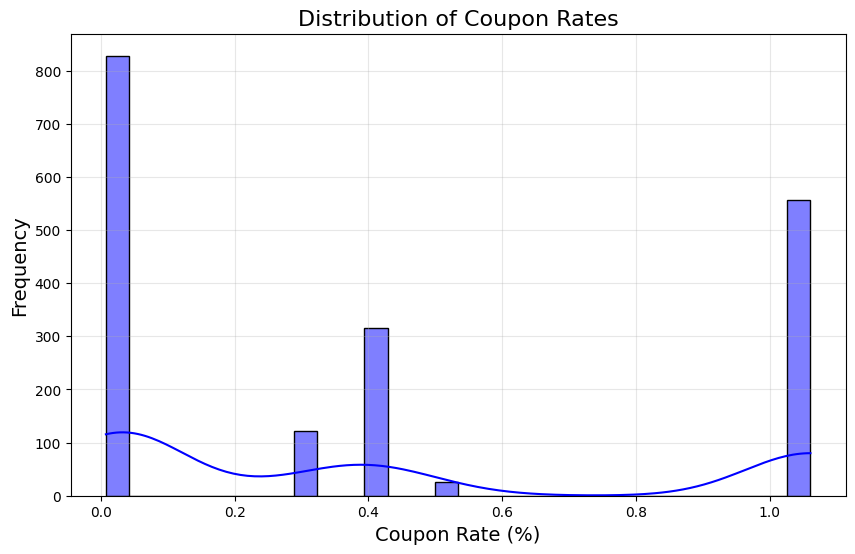

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop NA values from coupon_rate
coupon_rates = mapped_data['coupon_rate'].dropna()

# Set up the plot
plt.figure(figsize=(10, 6))

# Histogram with KDE
sns.histplot(coupon_rates, kde=True, bins=30, color='blue', edgecolor='black')

# Add labels and title
plt.title('Distribution of Coupon Rates', fontsize=16)
plt.xlabel('Coupon Rate (%)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Show plot
plt.grid(alpha=0.3)
plt.show()

In [32]:
# Convert PRICE, COMP_BID, COMP_ASK from dollar terms to yield terms
mapped_data['PRICE_YIELD'] = (mapped_data['coupon_rate'] / mapped_data['price']) * 100
mapped_data['COMP_BID_YIELD'] = (mapped_data['coupon_rate'] / mapped_data['bid_price']) * 100
mapped_data['COMP_ASK_YIELD'] = (mapped_data['coupon_rate'] / mapped_data['ask_price']) * 100


In [33]:
def calculate_slippage(row):
    if row['side'] == 'B':
        return (row['PRICE_YIELD'] - row['MID_yield']) / row['MID_yield'] * 10000
    elif row['side'] == 'S':
        return (row['MID_yield'] - row['PRICE_YIELD']) / row['MID_yield'] * 10000

# Calculate MID_yield for mapped_data
mapped_data['MID_yield'] = (mapped_data['COMP_BID_YIELD'] + mapped_data['COMP_ASK_YIELD']) / 2

# Calculate Slippage in Basis Points (bps)
mapped_data['slippage_bps'] = mapped_data.apply(calculate_slippage, axis=1)


In [34]:
Q1 = mapped_data['slippage_bps'].quantile(0.25)
Q3 = mapped_data['slippage_bps'].quantile(0.75)
IQR = Q3 - Q1

# Define Outlier Boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag Outliers
mapped_data['is_outlier'] = (mapped_data['slippage_bps'] < lower_bound) | \
                            (mapped_data['slippage_bps'] > upper_bound)

# Summary of Outliers
outliers = mapped_data[mapped_data['is_outlier']]
outliers

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,bid_price,ask_size,ask_price,coupon_rate,PRICE_YIELD,COMP_BID_YIELD,COMP_ASK_YIELD,MID_yield,slippage_bps,is_outlier
8132,2024-09-06,2024-09-06 12:57:59.332,2024-09-06 12:57:59.327,2024-09-06 08:57:59.327,569232.0,7022481282,7022480941,694809799.0,SHLYUBUU,YPQBABAQ,...,103.984375,2.0,104.046875,0.408,0.390906,0.392367,0.392131,0.392249,34.245552,True
8151,2024-09-06,2024-09-06 12:58:01.436,2024-09-06 12:58:01.433,2024-09-06 08:58:01.433,569232.0,7022481636,7022480941,694809880.0,SHLYUBUU,YPQBABAQ,...,104.000000,4.0,104.046875,0.408,0.390869,0.392308,0.392131,0.392219,34.429067,True
8153,2024-09-06,2024-09-06 12:58:01.863,2024-09-06 12:58:01.857,2024-09-06 08:58:01.857,569232.0,7022481673,7022480941,694809894.0,SHLYUBUU,YPQBABAQ,...,104.000000,4.0,104.046875,0.408,0.390876,0.392308,0.392131,0.392219,34.242596,True
8159,2024-09-06,2024-09-06 12:58:02.305,2024-09-06 12:58:02.302,2024-09-06 08:58:02.302,569232.0,7022481772,7022480941,694809865.0,SHLYUBUU,YPQBABAQ,...,104.000000,4.0,104.046875,0.408,0.390876,0.392308,0.392131,0.392219,34.242596,True
8164,2024-09-06,2024-09-06 12:58:02.806,2024-09-06 12:58:02.800,2024-09-06 08:58:02.800,569232.0,7022481851,7022480941,694809821.0,SHLYUBUU,YPQBABAQ,...,104.000000,4.0,104.046875,0.408,0.390869,0.392308,0.392131,0.392219,34.429067,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1755348,2024-08-15,2024-08-15 13:41:49.271,2024-08-15 13:41:49.261,2024-08-15 09:41:49.261,552001.0,7017282760,7017258863,690806982.0,JNOGPDBN,CAIUFPKI,...,104.328125,4.0,104.406250,0.305,0.293324,0.292347,0.292128,0.292237,-37.190074,True
1755349,2024-08-15,2024-08-15 13:41:49.288,2024-08-15 13:41:49.275,2024-08-15 09:41:49.275,552001.0,7017282777,7017258863,690806978.0,JNOGPDBN,CAIUFPKI,...,104.328125,4.0,104.406250,0.305,0.293324,0.292347,0.292128,0.292237,-37.190074,True
1755350,2024-08-15,2024-08-15 13:41:50.626,2024-08-15 13:41:50.610,2024-08-15 09:41:50.610,552001.0,7017282825,7017258863,690806967.0,JNOGPDBN,CAIUFPKI,...,104.343750,3.0,104.406250,0.305,0.293319,0.292303,0.292128,0.292216,-37.753378,True
1755351,2024-08-15,2024-08-15 13:41:52.754,2024-08-15 13:41:52.744,2024-08-15 09:41:52.744,552001.0,7017282906,7017258863,690807016.0,JNOGPDBN,CAIUFPKI,...,104.343750,3.0,104.406250,0.305,0.293324,0.292303,0.292128,0.292216,-37.941923,True


# Markout LP Analysis

In [35]:
import pandas as pd

trading_data['timestamp'] = pd.to_datetime(trading_data['timestamp'])

# 'B' for Buy, 'S' for Sell
trading_data['order_flow'] = trading_data['side'].map({'B': 1, 'S': -1}) * trading_data['quantity']

# Round the timestamp to the nearest 10 seconds for grouping
trading_data['time_rounded'] = trading_data['timestamp'].dt.floor('10S')

# Group by the rounded timestamp and sum the order flows for each 10-second interval
order_flow_aggregated = trading_data.groupby('time_rounded')['order_flow'].sum().reset_index()
order_flow_aggregated

<ipython-input-35-b6a99e308ebb>:9: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  trading_data['time_rounded'] = trading_data['timestamp'].dt.floor('10S')


,time_rounded,order_flow
0,2024-08-02 11:56:30,-17.0
1,2024-08-02 12:03:00,-51.0
2,2024-08-02 12:03:30,-81.0
3,2024-08-02 12:03:40,-23.0
4,2024-08-02 12:33:40,15.0
...,...,...
229171,2024-10-31 20:59:00,-11.0
229172,2024-10-31 20:59:10,-140.0
229173,2024-10-31 20:59:20,4.0
229174,2024-10-31 20:59:30,-20.0


In [36]:
# bond
symbols_list = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']

selected_data = mapped_data[mapped_data['symbol'].isin(symbols_list)]

In [37]:
# Count the number of unique trades using 'orderid' or 'executionid'
unique_trades_count = selected_data['orderid'].nunique()

multi_leg_trades = selected_data[
    selected_data['syntheticcontractidentifier'].notna() |
    selected_data['syntheticcontractdefinition'].notna()
]

multi_leg_trades_count = multi_leg_trades['orderid'].nunique()

print(f"Total unique trades: {unique_trades_count}")
print(f"Total multi-leg trades: {multi_leg_trades_count}")

Total unique trades: 1438723
Total multi-leg trades: 1435009


In [38]:
# Count the number of unique LPs in the dataset
unique_lps_count = selected_data['exchange_lp'].nunique()
print(f"Total unique LPs in the dataset: {unique_lps_count}")

# Count the number of hedge trades versus regular trades
hedge_trades = selected_data[selected_data['quote_or_hedge'] == 'Hedge']
hedge_trades_count = hedge_trades['orderid'].nunique()
regular_trades_count = unique_trades_count - hedge_trades_count

print(f"Number of hedge trades: {hedge_trades_count}")
print(f"Number of regular trades: {regular_trades_count}")

Total unique LPs in the dataset: 22
Number of hedge trades: 630763
Number of regular trades: 807960


In [39]:
selected_data.columns

Index(['trade_date', 'executiontime', 'brokerexecutiontime', 'exec_time_et',
       'recapid', 'orderid', 'parentcorrelationorderid', 'executionid', 'firm',
       'client', 'syntheticcontractidentifier', 'instrument',
       'syntheticpricemode', 'syntheticticksize',
       'syntheticcontractdefinition', 'security_type', 'symbol', 'cusip',
       'side', 'quantity', 'price', 'order_source', 'broker_id', 'exchange',
       'exchange_route', 'exchange_endoint', 'exchange_lp', 'is_aggressive',
       'destination', 'order_text', 'quote_or_hedge', 'hedge_target_price',
       'cash_exchange_trade_id', 'timestamp', 'build_id', 'build_name',
       'hide_duration', 'pop_ticks', 'label', 'time_diff', 'order_flow',
       'time_rounded', 'executiontime_10s', 'time', 'bid_size', 'bid_price',
       'ask_size', 'ask_price', 'coupon_rate', 'PRICE_YIELD', 'COMP_BID_YIELD',
       'COMP_ASK_YIELD', 'MID_yield', 'slippage_bps', 'is_outlier'],
      dtype='object')

In [40]:
import pandas as pd

# Assuming 'selected_data' is your dataframe and 'timestamp' is already in datetime format
selected_data['timestamp'] = pd.to_datetime(selected_data['timestamp'])

# Create a 'order_flow' column as you did earlier
selected_data['order_flow'] = selected_data['side'].map({'B': 1, 'S': -1}) * selected_data['quantity']

# 1. Instant (no aggregation)
# Each individual trade is considered its own "instant"
instant_data = selected_data[['timestamp', 'order_flow']]

# 2. 10s, 30s, 60s, 1hr intervals (round to nearest time period and aggregate)
time_intervals = ['10S', '30S', '60S', '1H']  # 10 seconds, 30 seconds, 1 minute (60 seconds), 1 hour

# Round the timestamp to the nearest time interval and group by it
for interval in time_intervals:
    selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)  # Round to nearest interval
    aggregated_data = selected_data.groupby('time_rounded')['order_flow'].sum().reset_index()
    print(f"Order flow aggregated by {interval}:")
    print(aggregated_data.head())

# 3. EOD (End of Day)
# Group by the date (ignoring time) and aggregate order flow for each day
selected_data['date'] = selected_data['timestamp'].dt.date  # Extract date part
eod_data = selected_data.groupby('date')['order_flow'].sum().reset_index()
print("Order flow aggregated by End of Day (EOD):")
print(eod_data.head())


<ipython-input-40-ade99c17d536>:18: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)  # Round to nearest interval
<ipython-input-40-ade99c17d536>:18: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)  # Round to nearest interval


Order flow aggregated by 10S:
         time_rounded  order_flow
0 2024-08-04 23:44:40        -1.0
1 2024-08-04 23:44:50        -4.0
2 2024-08-04 23:45:00        -8.0
3 2024-08-04 23:45:10        -1.0
4 2024-08-04 23:45:30        -1.0
Order flow aggregated by 30S:
         time_rounded  order_flow
0 2024-08-04 23:44:30        -5.0
1 2024-08-04 23:45:00        -9.0
2 2024-08-04 23:45:30        -1.0
3 2024-08-04 23:51:00        -3.0
4 2024-08-04 23:52:00         0.0


<ipython-input-40-ade99c17d536>:18: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)  # Round to nearest interval
<ipython-input-40-ade99c17d536>:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)  # Round to nearest interval


Order flow aggregated by 60S:
         time_rounded  order_flow
0 2024-08-04 23:44:00        -5.0
1 2024-08-04 23:45:00       -10.0
2 2024-08-04 23:51:00        -3.0
3 2024-08-04 23:52:00         0.0
4 2024-08-04 23:53:00        -4.0
Order flow aggregated by 1H:
         time_rounded  order_flow
0 2024-08-04 23:00:00       -22.0
1 2024-08-05 00:00:00        28.0
2 2024-08-05 01:00:00      -100.0
3 2024-08-05 02:00:00        -8.0
4 2024-08-05 03:00:00       -91.0
Order flow aggregated by End of Day (EOD):
         date  order_flow
0  2024-08-04       -22.0
1  2024-08-05      2423.0
2  2024-08-06      3342.0
3  2024-08-07      7380.0
4  2024-08-08      5447.0


In [41]:
import pandas as pd

# Assuming 'selected_data' is your dataframe and 'timestamp' is already in datetime format
selected_data['timestamp'] = pd.to_datetime(selected_data['timestamp'])

# Create a 'order_flow' column as you did earlier
selected_data['order_flow'] = selected_data['side'].map({'B': 1, 'S': -1}) * selected_data['quantity']

# Calculate market value for each trade (assuming 'price' and 'quantity' are columns)
selected_data['market_value'] = selected_data['quantity'] * selected_data['price']

# 1. Identify the top 3 synthetic contracts traded by the LPs in market value
top_3_contracts = selected_data.groupby(['exchange_lp', 'instrument'])['market_value'].sum().reset_index()
top_3_contracts = top_3_contracts.sort_values(by='market_value', ascending=False)

# Find the top 3 contracts for each LP
top_3_per_lp = top_3_contracts.groupby('exchange_lp').head(3).reset_index(drop=True)
print("Top 3 synthetic contracts traded by each LP in market value:")
print(top_3_per_lp)

# 2. Market value of all trades completed for that instrument by the LP
market_value_per_instrument = selected_data.groupby(['exchange_lp', 'instrument'])['market_value'].sum().reset_index()
print("Market value of all trades completed by the LP for each instrument:")
print(market_value_per_instrument)

# 3. Calculate markout for LPs at different time frames (instant, 10s, 30s, 60s, 1hr, EOD, etc.)
# We assume that 'price' is the trade price and 'timestamp' is the time of execution

# For the markout calculation, you can use your previously defined method (e.g., with event timestamps and mid-prices).

# Assuming `markout_function` is defined for calculating the markout at different time frames
# Define time intervals for markout calculation
time_intervals = ['10S', '30S', '60S', '1H']  # 10 seconds, 30 seconds, 1 minute (60 seconds), 1 hour

# Aggregate markout for each LP and time interval
for interval in time_intervals:
    selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)
    # Assuming you have a markout function to calculate markout at each interval
    aggregated_markout = selected_data.groupby(['exchange_lp', 'time_rounded'])['market_value'].sum().reset_index()
    print(f"Market value and markout aggregated by {interval}:")
    print(aggregated_markout.head())

# For EOD (End of Day) aggregation
selected_data['date'] = selected_data['timestamp'].dt.date  # Extract date part
eod_data = selected_data.groupby(['exchange_lp', 'date'])['market_value'].sum().reset_index()
print("Market value aggregated by End of Day (EOD):")
print(eod_data.head())


Top 3 synthetic contracts traded by each LP in market value:
   exchange_lp              instrument  market_value
0     WKWSDLYV            CT5-CT10 (Y)  4.946693e+06
1     WKWSDLYV            CT5-CT30 (Y)  4.414663e+06
2     WKWSDLYV       CT5-CT10-CT30 (Y)  4.410075e+06
3     SBUWHHFR            CT5-CT10 (Y)  2.796593e+06
4     OQFTYCMP            CT5-CT10 (Y)  2.222554e+06
..         ...                     ...           ...
61    XJLFBBMG       CT5-CT10-CT30 (Y)  1.023779e+04
62    HVCLDWPA            CT2-CT10 (Y)  7.195340e+03
63    IMFZQERH  CT3-CT5-CT10 (Y) (DRD)  2.593355e+03
64    IMFZQERH            CT5-CT10 (Y)  6.107188e+02
65    IMFZQERH             CT5-CT7 (Y)  5.088633e+02

[66 rows x 3 columns]
Market value of all trades completed by the LP for each instrument:
      exchange_lp                              instrument  market_value
0        COMENLHK             C23710US20 CLEAN UP ONE OFF    201.431641
1        COMENLHK                           CT10-CNZ4 (Y)    397.808

<ipython-input-41-a384fdbf3729>:37: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)


Market value and markout aggregated by 10S:
  exchange_lp        time_rounded  market_value
0    COMENLHK 2024-08-05 12:14:30    102.240234
1    COMENLHK 2024-08-05 12:27:30    220.488281
2    COMENLHK 2024-08-05 12:37:10    607.898438
3    COMENLHK 2024-08-05 12:37:20    303.972656
4    COMENLHK 2024-08-05 13:16:10    105.632812


<ipython-input-41-a384fdbf3729>:37: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)


Market value and markout aggregated by 30S:
  exchange_lp        time_rounded  market_value
0    COMENLHK 2024-08-05 12:14:30    102.240234
1    COMENLHK 2024-08-05 12:27:30    220.488281
2    COMENLHK 2024-08-05 12:37:00    911.871094
3    COMENLHK 2024-08-05 13:16:00    105.632812
4    COMENLHK 2024-08-05 14:51:30    109.832031


<ipython-input-41-a384fdbf3729>:37: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)


Market value and markout aggregated by 60S:
  exchange_lp        time_rounded  market_value
0    COMENLHK 2024-08-05 12:14:00    102.240234
1    COMENLHK 2024-08-05 12:27:00    220.488281
2    COMENLHK 2024-08-05 12:37:00    911.871094
3    COMENLHK 2024-08-05 13:16:00    105.632812
4    COMENLHK 2024-08-05 14:51:00    109.832031


<ipython-input-41-a384fdbf3729>:37: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  selected_data['time_rounded'] = selected_data['timestamp'].dt.floor(interval)


Market value and markout aggregated by 1H:
  exchange_lp        time_rounded  market_value
0    COMENLHK 2024-08-05 12:00:00   1234.599609
1    COMENLHK 2024-08-05 13:00:00    105.632812
2    COMENLHK 2024-08-05 14:00:00    318.308594
3    COMENLHK 2024-08-05 15:00:00    101.822266
4    COMENLHK 2024-08-05 16:00:00    514.828125
Market value aggregated by End of Day (EOD):
  exchange_lp        date  market_value
0    COMENLHK  2024-08-05   2376.144531
1    COMENLHK  2024-08-06   5067.734375
2    COMENLHK  2024-08-07   8543.148438
3    COMENLHK  2024-08-08   5426.673828
4    COMENLHK  2024-08-09   9946.894531


In [42]:
selected_data['MID_yield'] = (selected_data['COMP_BID_YIELD'] + selected_data['COMP_ASK_YIELD']) / 2

# Function to calculate markout
def calculate_markout(row, future_mid_yield=None):
    if row['side'] == 'B':  # Buy
        # Buy Markout formula: Compare trade price with mid yield
        return (row['MID_yield'] - row['PRICE_YIELD']) / row['PRICE_YIELD'] * 10000
    elif row['side'] == 'S':  # Sell
        # Sell Markout formula: Compare future mid price (at future timestamp) with trade price
        return (row['PRICE_YIELD'] - row['MID_yield']) / row['PRICE_YIELD'] * 10000

selected_data['markout'] = selected_data.apply(calculate_markout, axis=1)
selected_data['markout']

KeyboardInterrupt: 

In [ ]:
# Calculate MID_yield for mapped_data
mapped_data['MID_yield'] = (mapped_data['COMP_BID_YIELD'] + mapped_data['COMP_ASK_YIELD']) / 2

def calculate_markout(row, mid_yield):
    if row['side'] == 'B':  # Buy
        return (row['MID_yield'] - row['PRICE_YIELD']) / row['PRICE_YIELD'] * 10000
    elif row['side'] == 'S':  # Sell
        return (row['MID_yield'] - future_mid_yield) / row['PRICE_YIELD'] * 10000

# Example offsets in seconds
offsets = [10, 30, 60, 3600, 43200]  # 10s, 30s, 1min, 1hr, 12hr


# Model

In [ ]:
mapped_data['price_variation'] = mapped_data['price'].diff()  # e.g., for each time interval
mapped_data['order_flow'] = mapped_data['quantity'] * mapped_data['side'].apply(lambda x: 1 if x == 'BUY' else -1)
mapped_data['']
Sigma = price_variations.cov()
Omega = order_flows.cov()
R = price_variations.cov(order_flows)

In [ ]:
from scipy.optimize import minimize

def objective(Y, Sigma, Omega, R):
    # Define your objective function (e.g., squared error between predicted and actual price changes)
    prediction_error = np.sum((predicted_price_changes - actual_price_changes) ** 2)
    return prediction_error

Y_init = 1  # initial guess
result = minimize(objective, Y_init, args=(Sigma, Omega, R))
Y = result.x  # optimized Y-ratio

# Diagonal Model

In [ ]:
Lambda_diag = Y * np.diag(R).dot(np.diag(np.linalg.inv(Omega)))
Lambda_ML = Y * R.dot(np.linalg.inv(Omega))
Lambda_Kyle = Y * np.linalg.inv(Omega)**0.5.T.dot(np.linalg.inv(Omega)**0.5.T.dot(Sigma).dot(np.linalg.inv(Omega)**0.5))


# Model Evaluation

In [ ]:
from sklearn.metrics import r2_score

r2_diag = r2_score(actual_price_changes, predicted_price_changes_diag)
r2_ML = r2_score(actual_price_changes, predicted_price_changes_ML)
r2_Kyle = r2_score(actual_price_changes, predicted_price_changes_Kyle)